# spaCy

In [1]:
import spacy
import pandas as pd
import itertools as it

In [2]:
nlp = spacy.load('es_core_news_lg')

# Phrase modelling

In [3]:
import codecs
from gensim.models import Phrases
from gensim.models.word2vec import LineSentence

c:\Users\eduardo.moreno\AppData\Local\anaconda3\envs\env_nlp\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


In [4]:
def line_review(filename):
    """
    generator function to read in reviews from the file
    and un-escape the original line breaks in the text
    """
    
    with codecs.open(filename, encoding='utf_8') as f:
        for review in f:
            yield review.replace('\\n', '\n')

## Unigrams

In [5]:
df = pd.read_pickle(r"..\..\..\data\preprocessed\clean_stemm_lemm_stop_words_fb_groups_uniques.pkl")

In [6]:
df.head()

,Facebook Id,Post Created,Total Interactions,Likes,Comments,Shares,Love,Wow,Haha,Sad,Angry,Care,Message_stpWrd,Message_clean_stpWrd,Message_clean_stemm_stpWrd,Message_clean_lemm_stpWrd
0,153630631414604,2016-01-05 20:55:17 CST,"7,836",7266,442,63,51,1,9,2,0,2,NACIDOS 1970 1987 generación especial denomina...,nacidos 1970 1987 generacion especial denomina...,nac 1970 1987 som gener especial denomin gener...,nacido 1970 1987 generacion especial denominar...
1,344760762323803,2018-03-25 20:22:33 CST,"12,530",2946,44,9025,357,4,112,7,17,18,VOTARE GUSTAVO PETRO quiero compartir ustedes ...,votare gustavo petro quiero compartir ustedes ...,porqu votar gustav petr quier compart seguidor...,votare gustavo petro querer compartir seguidor...
2,663135523805166,2018-04-26 15:23:31 CDT,"3,727",2137,77,917,583,10,2,0,1,0,"Ministra medio ambiente, cambio climático desc...",ministra medio ambiente cambio climatico desca...,ministr medi ambient trabaj cambi climat desca...,ministra medio ambiente cambio climatico desca...
3,461295120574213,2016-05-02 17:59:04 CDT,"3,146",2548,249,188,123,7,28,2,1,0,NACIDOS 1970 1987 generación especial denomina...,nacidos 1970 1987 generacion especial denomina...,nac 1970 1987 som gener especial denomin gener...,nacido 1970 1987 generacion especial denominar...
4,663135523805166,2016-06-28 23:41:26 CDT,"2,804",2367,57,181,87,5,3,8,96,0,AYÚDANOS COMPARTIR IMAGEN.. magnicfico POT (Pl...,ayudanos compartir imagen magnicfico pot plan ...,ayudan compart imag magnicf pot plan orden ter...,ayudano compartir imagen magnicfico pot plan o...


In [7]:
file_lemmatized_text = r'..\..\..\data\ngrams\fb-groups\lemmatized_text.txt'

if 1 == 0:
    with open(file_lemmatized_text, "w") as file:
        for item in df['Message_clean_lemm_stpWrd'].values.tolist():
            file.write(item + "\n")

In [8]:
unigram_sentences = LineSentence(file_lemmatized_text)

In [9]:
for unigram_sentence in it.islice(unigram_sentences, 230, 240):
    print(' '.join(unigram_sentence))
    print('')

pasar energia limpio futuro

petro populista propuesta colombia implementar politica economica social medioambiental manejar uruguay dia

ministro deberar dedicar sabado replantar arbol pais

asi equipar avion toxico nanoparticula geoingenierio chemtrails quimico toxico veneno cielo asi instalar quimico avion asi fumigar asi modificacion clima asi tirar quimico persona naturaleza crear mutacion modificacion traer enfermedad cosa chemtrails persona '' estela jet ignorancia '' hablar cambio climatico demas tema ciego estupidez humano

arbol talar animal extinguir rio secar humanidad entendera dinero mundo doloroso colosal cerro oriental flora fauna recurso natural perecer frente esperanza persona dia dia luchar mundo culpa gobierno negligente jamas tomar represarias cambio climatico dia realidad afectar bogota afectar nacion sociedad planeta aun asi buscar acabar reserva natural ten misericordia dios perdonanos ayudar tarde seaesto todosesto alcaso depronto alcansar quedar hijo

calentam

## Bigrams

In [10]:
%%time
bigram_model_filepath = r'..\..\models\ngrams\fb-groups\bigram_model_all'

# this is a bit time consuming - make the if statement True
# if you want to execute modeling yourself.
if 1 == 0:
    bigram_model = Phrases(unigram_sentences, min_count=250, threshold=20)
    bigram_model.save(bigram_model_filepath)
    
# load the finished model from disk
bigram_model = Phrases.load(bigram_model_filepath)

CPU times: total: 1.8 s
Wall time: 1.79 s


In [11]:
%%time
# this is a bit time consuming - make the if statement True
# if you want to execute data prep yourself.

bigram_sentences_filepath = r'..\..\..\data\ngrams\fb-groups\bigram_sentences_all.txt'

if 1 == 0:
    with codecs.open(bigram_sentences_filepath, 'w', encoding='utf_8') as f:
        for unigram_sentence in unigram_sentences:
            bigram_sentence = u' '.join(bigram_model[unigram_sentence])
            f.write(bigram_sentence + '\n')

CPU times: total: 0 ns
Wall time: 0 ns


In [12]:
bigram_sentences = LineSentence(bigram_sentences_filepath)

In [13]:
for bigram_sentence in it.islice(bigram_sentences, 230, 240):
    print(' '.join(bigram_sentence))
    print('')

pasar energia_limpio futuro

petro populista propuesta colombia implementar politica economica social medioambiental manejar uruguay dia

ministro deberar dedicar sabado replantar arbol pais

asi equipar avion toxico nanoparticula geoingenierio chemtrails quimico toxico veneno cielo asi instalar quimico avion asi fumigar asi modificacion clima asi tirar quimico persona naturaleza crear mutacion modificacion traer enfermedad cosa chemtrails persona '' estela jet ignorancia '' hablar cambio_climatico demas tema ciego estupidez humano

arbol talar animal extinguir rio secar humanidad entendera dinero mundo doloroso colosal cerro oriental flora_fauna recurso_natural perecer frente esperanza persona dia dia luchar mundo culpa gobierno negligente jamas tomar represarias cambio_climatico dia realidad afectar bogota afectar nacion sociedad planeta aun asi buscar acabar reserva natural ten misericordia dios perdonanos ayudar tarde seaesto todosesto alcaso depronto alcansar quedar hijo

calentam

## Trigrams

In [14]:
%%time
# this is a bit time consuming - make the if statement True
# if you want to execute modeling yourself.
trigram_model_filepath = r'..\..\models\ngrams\fb-groups\trigram_model_all'

if 1 == 0:
    trigram_model = Phrases(bigram_sentences, min_count=200, threshold=20)
    trigram_model.save(trigram_model_filepath)
    
# load the finished model from disk
trigram_model = Phrases.load(trigram_model_filepath)

CPU times: total: 1.75 s
Wall time: 1.75 s


In [15]:
%%time
# this is a bit time consuming - make the if statement True
# if you want to execute data prep yourself.

trigram_sentences_filepath = r'..\..\..\data\ngrams\fb-groups\trigram_sentences_all.txt'

if 1 == 0:
    with codecs.open(trigram_sentences_filepath, 'w', encoding='utf_8') as f:
        for bigram_sentence in bigram_sentences:
            trigram_sentence = u' '.join(trigram_model[bigram_sentence])
            f.write(trigram_sentence + '\n')

CPU times: total: 0 ns
Wall time: 0 ns


In [16]:
trigram_sentences = LineSentence(trigram_sentences_filepath)

In [17]:
for trigram_sentence in it.islice(trigram_sentences, 220, 230):
    print(' '.join(trigram_sentence))
    print('')

dia pachamama saludo cambio_climatico uruguay elizabeth gomez

inteligencia

habrir paz considerar cambio_climatico adaptacion variable construccion pais

opinar

12 minuto experto desmentir dato argumento solido hampon neoliberal penalosir mentira reserva der hammen destruir reserva der hammen aumentario efecto cambio_climatico ciudad destruir reserva condenar nieto tapaboca salir calle bogota deficit mas 1'500000 arbol minimo deber arbol 3 habitan reserva der hammen poseer fuente agua subterrranea seguir sembrar_arbol reserva 2do necesario pulmon aire bogota despues cerro oriental

brasil querer respiro naturaleza

gustavo_petro urrego presidente colombia ultraderecha donald_trump humanida salida unidos cambio_climatico desastre climatico mundial favorecer interes grande compania petrolero unidos interes poblacion_mundial contrario gustavo_petro presidente defender interes poblacion colombiano cambio_climatico

uribestias procuragodo infartado 3 2 1 v medio lanzamiento cumbre_clima s

In [18]:
%%time
# this is a bit time consuming - make the if statement True
# if you want to execute data prep yourself.

trigram_reviews_filepath = r'..\..\..\data\ngrams\fb-groups\trigram_transformed_reviews_all.txt'
trigram_reviews_filepath = trigram_sentences_filepath

CPU times: total: 0 ns
Wall time: 0 ns


In [19]:
print('Original:' + u'\n')
for review in it.islice(line_review(file_lemmatized_text), 11, 12):
    print(review)
print('----' + u'\n')
print('Transformed:' + u'\n')

with codecs.open(trigram_reviews_filepath, encoding='utf_8') as f:
    for review in it.islice(f, 11, 12):
        print(review)

Original:

cambio climatico francisco febres cordero domingo 29 noviembre 2015 chuta interesante manana comenzar francia cumbre cambio climatico participar excelentisimo senor presidente republica buenazo discurso tambien economista experto cambio ay clima quise dominar tema ojala mundo seguir pie letra recomendacion claro preguntar president asistir cumbre despues parrafo refregar estudiante ano cosmetologia sera cosmografia ay dificil terminologia cientifico seguro revelacion basado experiencia climologo mas clima cambiar tomar medida urgente achicharrar habitante planeta explicar sentir carne calentar pais calle tambien calentar calle excelentisimo senor presidente republica cien mil persona salir gritar calientisimas alarmar mundo calentamiento mil noma reconocer calentamiento tornar global jubilado afiliado desempleado trabajador indigena profesor perseguido peor sumar gas ordenar tirar serrano atentar capa ozono pobre calentado producir efecto invernadero pulmon horrible dano atm

# LDA

In [20]:
import warnings
import multiprocessing
from gensim.corpora import Dictionary, MmCorpus
from gensim.models.ldamulticore import LdaMulticore

In [21]:
trigram_dictionary_filepath = r'..\..\models\ngrams\fb-groups\trigram_dict_all.dict'

In [22]:
%%time

# this is a bit time consuming - make the if statement True
# if you want to learn the dictionary yourself.
if 1 == 0:

    trigram_reviews = LineSentence(trigram_reviews_filepath)

    # learn the dictionary by iterating over all of the reviews
    trigram_dictionary = Dictionary(trigram_reviews)
    
    # filter tokens that are very rare or too common from
    # the dictionary (filter_extremes) and reassign integer ids (compactify)
    trigram_dictionary.filter_extremes(no_below=300, no_above=0.4)
    trigram_dictionary.compactify()

    trigram_dictionary.save(trigram_dictionary_filepath)
    
# load the finished dictionary from disk
trigram_dictionary = Dictionary.load(trigram_dictionary_filepath)

CPU times: total: 0 ns
Wall time: 2.52 ms


In [23]:
trigram_bow_filepath = r'..\..\models\ngrams\fb-groups\trigram_bow_corpus_all.mm'

In [24]:
def trigram_bow_generator(filepath):
    """
    generator function to read reviews from a file
    and yield a bag-of-words representation
    """
    
    for review in LineSentence(filepath):
        yield trigram_dictionary.doc2bow(review)

In [25]:
%%time

# this is a bit time consuming - make the if statement True
# if you want to build the bag-of-words corpus yourself.
if 1 == 0:
    # generate bag-of-words representations for
    # all reviews and save them as a matrix
    MmCorpus.serialize(trigram_bow_filepath,
                       trigram_bow_generator(trigram_reviews_filepath))
# load the finished bag-of-words corpus from disk
trigram_bow_corpus = MmCorpus(trigram_bow_filepath)

CPU times: total: 46.9 ms
Wall time: 19.2 ms


In [26]:
lda_model_filepath = r'..\..\models\ngrams\fb-groups\lda_model_all'

In [27]:
pool = multiprocessing.Pool()
num_workers = pool._processes
print(f"Number of workers in the Pool: {num_workers}")

Number of workers in the Pool: 16


In [28]:
%%time

# this is a bit time consuming - make the if statement True
# if you want to train the LDA model yourself.
num_topics = 15

if 1 == 1:

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        
        # workers => sets the parallelism, and should be
        # set to your number of physical cores minus one
        lda = LdaMulticore(trigram_bow_corpus,
                           num_topics=num_topics,
                           id2word=trigram_dictionary,
                           workers=num_workers,
                           )
    
    lda.save(lda_model_filepath)
    
# load the finished LDA model from disk
lda = LdaMulticore.load(lda_model_filepath)

CPU times: total: 11.1 s
Wall time: 24.7 s


## Keywords

In [29]:
from matplotlib import pyplot as plt
from wordcloud import WordCloud
import matplotlib.colors as mcolors

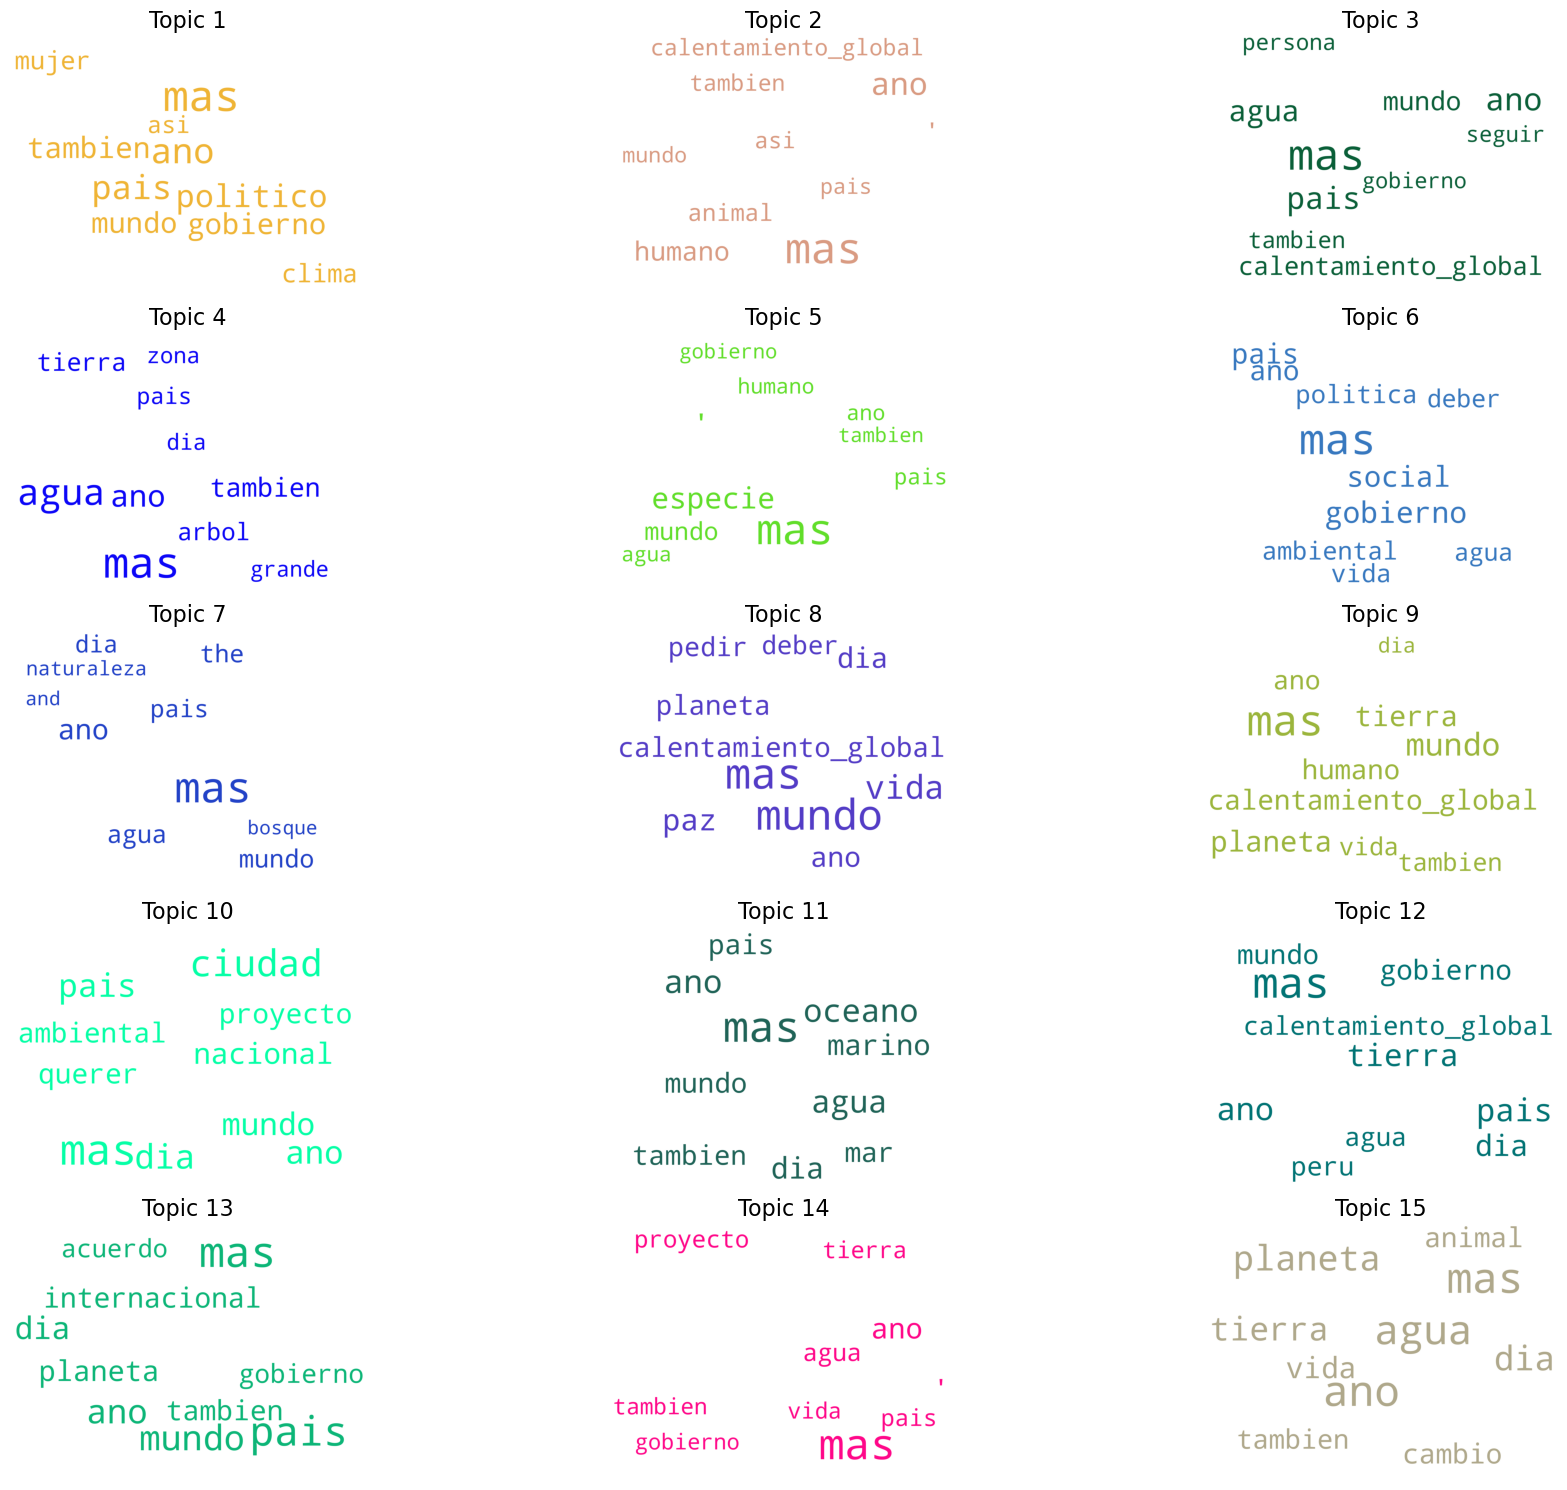

In [30]:
cols = [color for name, color in mcolors.XKCD_COLORS.items()]  # more colors: 'mcolors.XKCD_COLORS'
cols = cols[num_topics:num_topics*2]

cloud = WordCloud(background_color='white',
                  width=2500,
                  height=1800,
                  max_words=10,
                  colormap='tab10',
                  color_func=lambda *args, **kwargs: cols[i],
                  prefer_horizontal=1.0)

topics = lda.show_topics(formatted=False, num_topics=num_topics)

fig, axes = plt.subplots(5, 3, figsize=(20,15), sharex=True, sharey=True)

for i, ax in enumerate(axes.flatten()):
    fig.add_subplot(ax)
    topic_words = dict(topics[i][1])
    cloud.generate_from_frequencies(topic_words, max_font_size=300)
    plt.gca().imshow(cloud)
    plt.gca().set_title('Topic ' + str(i+1), fontdict=dict(size=16))
    plt.gca().axis('off')


plt.subplots_adjust(wspace=0, hspace=0)
plt.axis('off')
plt.margins(x=0, y=0)
plt.tight_layout()
plt.show()

In [31]:
def explore_topic(topic_number, topn=25):
    """
    accept a user-supplied topic number and
    print out a formatted list of the top terms
    """
        
    print('{:20} {}'.format(u'term', u'frequency') + u'\n')

    for term, frequency in lda.show_topic(topic_number, topn=topn):
        print('{:20} {:.3f}'.format(term, round(frequency, 3)))

In [32]:
for topic in range(num_topics):
    print(f"--- Topic: {topic + 1}")
    explore_topic(topic_number=topic, topn=10)
    print("")

--- Topic: 1
term                 frequency

mas                  0.011
ano                  0.007
pais                 0.007
politico             0.006
tambien              0.005
gobierno             0.005
mundo                0.005
clima                0.004
mujer                0.004
asi                  0.003

--- Topic: 2
term                 frequency

mas                  0.018
ano                  0.009
humano               0.006
animal               0.005
'                    0.004
calentamiento_global 0.004
asi                  0.004
tambien              0.004
pais                 0.004
mundo                0.004

--- Topic: 3
term                 frequency

mas                  0.017
ano                  0.008
pais                 0.008
agua                 0.007
mundo                0.006
calentamiento_global 0.005
tambien              0.004
persona              0.004
seguir               0.004
gobierno             0.004

--- Topic: 4
term                 frequency

mas    

In [33]:
lda.print_topics()

[(0,
  '0.011*"mas" + 0.007*"ano" + 0.007*"pais" + 0.006*"politico" + 0.005*"tambien" + 0.005*"gobierno" + 0.005*"mundo" + 0.004*"clima" + 0.004*"mujer" + 0.003*"asi"'),
 (1,
  '0.018*"mas" + 0.009*"ano" + 0.006*"humano" + 0.005*"animal" + 0.004*"\'" + 0.004*"calentamiento_global" + 0.004*"asi" + 0.004*"tambien" + 0.004*"pais" + 0.004*"mundo"'),
 (2,
  '0.017*"mas" + 0.008*"ano" + 0.008*"pais" + 0.007*"agua" + 0.006*"mundo" + 0.005*"calentamiento_global" + 0.004*"tambien" + 0.004*"persona" + 0.004*"seguir" + 0.004*"gobierno"'),
 (3,
  '0.016*"mas" + 0.011*"agua" + 0.007*"ano" + 0.005*"tambien" + 0.005*"tierra" + 0.005*"arbol" + 0.004*"pais" + 0.004*"zona" + 0.004*"dia" + 0.004*"grande"'),
 (4,
  '0.021*"mas" + 0.008*"especie" + 0.007*"\'" + 0.006*"mundo" + 0.004*"pais" + 0.004*"ano" + 0.004*"humano" + 0.004*"agua" + 0.004*"gobierno" + 0.004*"tambien"'),
 (5,
  '0.014*"mas" + 0.005*"gobierno" + 0.005*"social" + 0.005*"pais" + 0.005*"ano" + 0.004*"politica" + 0.004*"vida" + 0.004*"ambien